# EDA — US Accidents (PySpark)

**Rôle métier :** DOT / Collectivité territoriale

**Objectif de ce notebook :** explorer le jeu de données, comprendre les biais, et préparer la suite (détection de points noirs).

## 1. Setup Spark

In [1]:
import os
os.environ["JDK_JAVA_OPTIONS"] = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
    "--add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED "
    "--add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED "
    "--add-opens=java.base/sun.security.action=ALL-UNNAMED "
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED "
    "--add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED"
)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, BooleanType, TimestampType,
)

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("us_accidents_eda")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/18 16:36:28 WARN Utils: Your hostname, MacBook-Pro-de-Tristan.local, resolves to a loopback address: 127.0.0.1; using 10.90.133.166 instead (on interface en0)
26/05/18 16:36:28 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 16:36:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1


## 2. Chargement du CSV

Schéma explicite (évite la double passe `inferSchema`) et colonnes renommées en snake_case.

In [2]:
CSV_PATH = "US_Accidents_March23.csv"

schema = StructType([
    StructField("ID", StringType()),
    StructField("Source", StringType()),
    StructField("Severity", IntegerType()),
    StructField("Start_Time", TimestampType()),
    StructField("End_Time", TimestampType()),
    StructField("Start_Lat", DoubleType()),
    StructField("Start_Lng", DoubleType()),
    StructField("End_Lat", DoubleType()),
    StructField("End_Lng", DoubleType()),
    StructField("Distance(mi)", DoubleType()),
    StructField("Description", StringType()),
    StructField("Street", StringType()),
    StructField("City", StringType()),
    StructField("County", StringType()),
    StructField("State", StringType()),
    StructField("Zipcode", StringType()),
    StructField("Country", StringType()),
    StructField("Timezone", StringType()),
    StructField("Airport_Code", StringType()),
    StructField("Weather_Timestamp", TimestampType()),
    StructField("Temperature(F)", DoubleType()),
    StructField("Wind_Chill(F)", DoubleType()),
    StructField("Humidity(%)", DoubleType()),
    StructField("Pressure(in)", DoubleType()),
    StructField("Visibility(mi)", DoubleType()),
    StructField("Wind_Direction", StringType()),
    StructField("Wind_Speed(mph)", DoubleType()),
    StructField("Precipitation(in)", DoubleType()),
    StructField("Weather_Condition", StringType()),
    StructField("Amenity", BooleanType()),
    StructField("Bump", BooleanType()),
    StructField("Crossing", BooleanType()),
    StructField("Give_Way", BooleanType()),
    StructField("Junction", BooleanType()),
    StructField("No_Exit", BooleanType()),
    StructField("Railway", BooleanType()),
    StructField("Roundabout", BooleanType()),
    StructField("Station", BooleanType()),
    StructField("Stop", BooleanType()),
    StructField("Traffic_Calming", BooleanType()),
    StructField("Traffic_Signal", BooleanType()),
    StructField("Turning_Loop", BooleanType()),
    StructField("Sunrise_Sunset", StringType()),
    StructField("Civil_Twilight", StringType()),
    StructField("Nautical_Twilight", StringType()),
    StructField("Astronomical_Twilight", StringType()),
])

df_raw = (
    spark.read
    .option("header", True)
    .schema(schema)
    .csv(CSV_PATH)
)

rename_map = {
    "Distance(mi)": "distance_mi",
    "Temperature(F)": "temperature_f",
    "Wind_Chill(F)": "wind_chill_f",
    "Humidity(%)": "humidity_pct",
    "Pressure(in)": "pressure_in",
    "Visibility(mi)": "visibility_mi",
    "Wind_Speed(mph)": "wind_speed_mph",
    "Precipitation(in)": "precipitation_in",
}
df = df_raw
for old, new in rename_map.items():
    df = df.withColumnRenamed(old, new)
df = df.toDF(*[c.lower() for c in df.columns])

df.printSchema()

root
 |-- id: string (nullable = true)
 |-- source: string (nullable = true)
 |-- severity: integer (nullable = true)
 |-- start_time: timestamp (nullable = true)
 |-- end_time: timestamp (nullable = true)
 |-- start_lat: double (nullable = true)
 |-- start_lng: double (nullable = true)
 |-- end_lat: double (nullable = true)
 |-- end_lng: double (nullable = true)
 |-- distance_mi: double (nullable = true)
 |-- description: string (nullable = true)
 |-- street: string (nullable = true)
 |-- city: string (nullable = true)
 |-- county: string (nullable = true)
 |-- state: string (nullable = true)
 |-- zipcode: string (nullable = true)
 |-- country: string (nullable = true)
 |-- timezone: string (nullable = true)
 |-- airport_code: string (nullable = true)
 |-- weather_timestamp: timestamp (nullable = true)
 |-- temperature_f: double (nullable = true)
 |-- wind_chill_f: double (nullable = true)
 |-- humidity_pct: double (nullable = true)
 |-- pressure_in: double (nullable = true)
 |-- visi

In [3]:
# Mise en cache : on va requeter ce DF plusieurs fois
df.cache()
n_rows = df.count()
print(f"Nombre de lignes : {n_rows:,}")
print(f"Nombre de colonnes : {len(df.columns)}")

26/05/18 16:36:40 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Nombre de lignes : 7,728,394
Nombre de colonnes : 46


## 3. Valeurs manquantes

In [4]:
import pandas as pd

missing = df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in df.columns
]).toPandas().T
missing.columns = ["n_missing"]
missing["pct_missing"] = (missing["n_missing"] / n_rows * 100).round(2)
missing.sort_values("pct_missing", ascending=False).head(20)

,n_missing,pct_missing
end_lat,3402762,44.03
end_lng,3402762,44.03
precipitation_in,2203586,28.51
wind_chill_f,1999019,25.87
wind_speed_mph,571233,7.39
visibility_mi,177098,2.29
wind_direction,175206,2.27
humidity_pct,174144,2.25
weather_condition,173459,2.24
temperature_f,163853,2.12


## 4. Distribution de la sévérité (cible métier)

   severity    count    pct
0         1    67366   0.87
1         2  6156981  79.67
2         3  1299337  16.81
3         4   204710   2.65


/var/folders/gs/p910rpxs1571bgxrdf5c0zv00000gn/T/ipykernel_40759/1155379943.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sev, x="severity", y="count", ax=ax, palette="Reds")


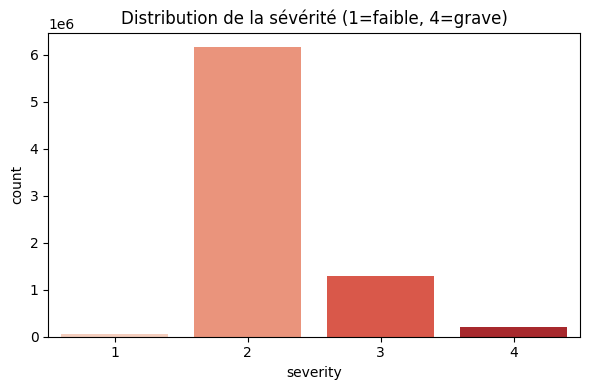

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sev = df.groupBy("severity").count().orderBy("severity").toPandas()
sev["pct"] = (sev["count"] / sev["count"].sum() * 100).round(2)
print(sev)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=sev, x="severity", y="count", ax=ax, palette="Reds")
ax.set_title("Distribution de la sévérité (1=faible, 4=grave)")
plt.tight_layout()

## 5. Couverture géographique et temporelle (biais)

Nombre d'états : 49
   state    count
0     CA  1741433
1     FL   880192
2     TX   582837
3     SC   382557
4     NY   347960
5     NC   338199
6     VA   303301
7     PA   296620
8     MN   192084
9     OR   179660
10    AZ   170609
11    GA   169234
12    IL   168958
13    TN   167388
14    MI   162191


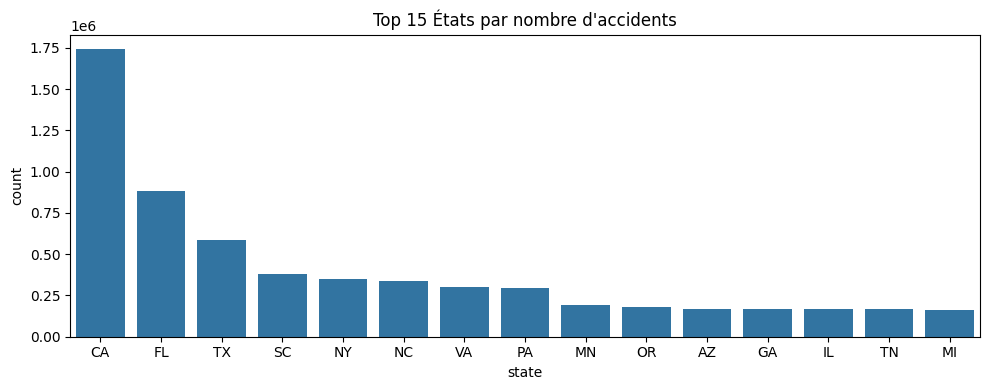

In [6]:
# Top 15 États par volume
by_state = df.groupBy("state").count().orderBy(F.desc("count")).toPandas()
print("Nombre d'états :", len(by_state))
print(by_state.head(15))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=by_state.head(15), x="state", y="count", ax=ax)
ax.set_title("Top 15 États par nombre d'accidents")
plt.tight_layout()

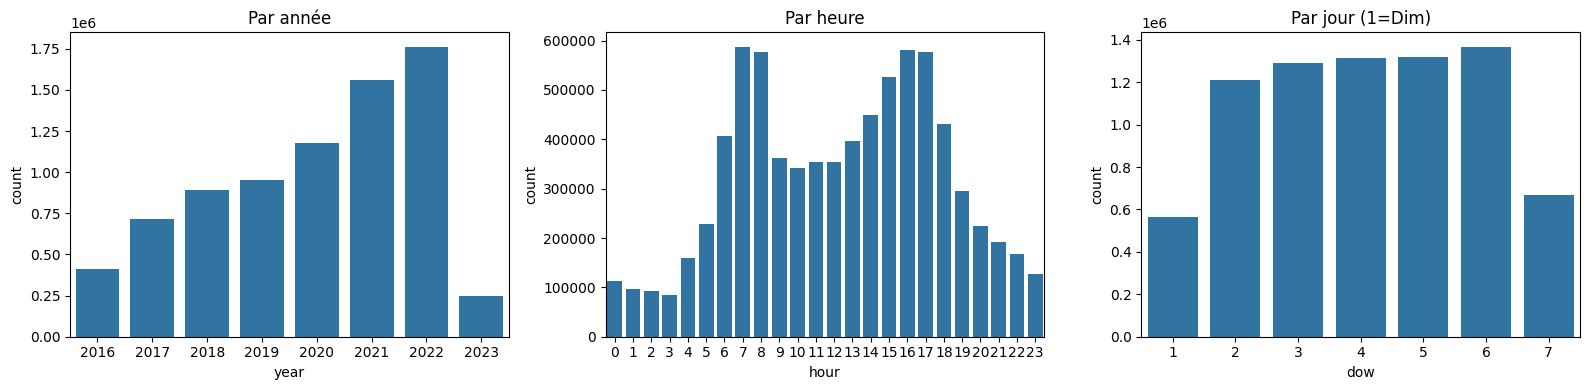

In [7]:
# Distribution temporelle : année, mois, jour de semaine, heure
df_t = df.withColumn("year", F.year("start_time")) \
         .withColumn("month", F.month("start_time")) \
         .withColumn("dow", F.dayofweek("start_time")) \
         .withColumn("hour", F.hour("start_time"))

by_year = df_t.groupBy("year").count().orderBy("year").toPandas()
by_hour = df_t.groupBy("hour").count().orderBy("hour").toPandas()
by_dow = df_t.groupBy("dow").count().orderBy("dow").toPandas()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=by_year, x="year", y="count", ax=axes[0]); axes[0].set_title("Par année")
sns.barplot(data=by_hour, x="hour", y="count", ax=axes[1]); axes[1].set_title("Par heure")
sns.barplot(data=by_dow, x="dow", y="count", ax=axes[2]); axes[2].set_title("Par jour (1=Dim)")
plt.tight_layout()

## 6. Sévérité moyenne par facteur (premières pistes métier DOT)

In [8]:
# Sévérité moyenne selon la présence/absence d'infrastructure routière
infra_cols = [
    "amenity", "bump", "crossing", "give_way", "junction", "no_exit",
    "railway", "roundabout", "station", "stop", "traffic_calming",
    "traffic_signal", "turning_loop",
]

rows = []
for col in infra_cols:
    agg = df.groupBy(col).agg(
        F.count("*").alias("n"),
        F.avg("severity").alias("avg_severity"),
    ).toPandas()
    for _, r in agg.iterrows():
        rows.append({"feature": col, "present": r[col], "n": r["n"], "avg_severity": r["avg_severity"]})

infra_df = pd.DataFrame(rows)
pivot = infra_df.pivot(index="feature", columns="present", values="avg_severity").round(3)
pivot.columns = ["sans", "avec"]
pivot["delta"] = (pivot["avec"] - pivot["sans"]).round(3)
pivot.sort_values("delta", ascending=False)

,sans,avec,delta
feature,,,
junction,2.206,2.298,0.092
give_way,2.213,2.179,-0.034
railway,2.213,2.159,-0.054
traffic_calming,2.212,2.127,-0.085
no_exit,2.213,2.112,-0.101
bump,2.212,2.094,-0.118
stop,2.216,2.076,-0.140
station,2.216,2.075,-0.141
amenity,2.214,2.070,-0.144


In [9]:
# Sévérité moyenne jour vs nuit
day_night = df.groupBy("sunrise_sunset").agg(
    F.count("*").alias("n"),
    F.avg("severity").alias("avg_severity"),
).toPandas()
print(day_night)

  sunrise_sunset        n  avg_severity
0            NaN    23246      2.216510
1          Night  2370595      2.219069
2            Day  5334553      2.209396


In [10]:
# Top conditions météo par volume + sévérité moyenne
weather = df.groupBy("weather_condition").agg(
    F.count("*").alias("n"),
    F.avg("severity").alias("avg_severity"),
).orderBy(F.desc("n")).toPandas()
weather.head(15)

,weather_condition,n,avg_severity
0,Fair,2560802,2.127027
1,Mostly Cloudy,1016195,2.222067
2,Cloudy,817082,2.160340
3,Clear,808743,2.367950
4,Partly Cloudy,698972,2.217851
5,Overcast,382866,2.385422
6,Light Rain,352957,2.247846
7,Scattered Clouds,204829,2.380347
8,NaN,173459,2.254809
9,Light Snow,128680,2.245291


## 7. Premières observations

_(À remplir au fil de l'exécution)_

- Volume total :
- États dominants :
- Période couverte :
- Biais détectés :
- Features infra avec plus fort impact sévérité :

## 8. Sauvegarde en Parquet pour les notebooks suivants

In [11]:
# Écriture une fois en Parquet partitionné par État
# Les notebooks suivants relisent ce Parquet : 10-50x plus rapide que le CSV
(
    df.write
    .mode("overwrite")
    .partitionBy("state")
    .parquet("data/accidents.parquet")
)
print("Parquet écrit dans data/accidents.parquet")

Parquet écrit dans data/accidents.parquet
